# Other features

Evaluate whether mcPHASES signals beyond the standard pipeline improve fatigue prediction when added.

**New features tested:**
- `glucose.csv`: timestamp (every 5 min) → daily median of `glucose_value` (varies across the menstrual cycle)
- `heart_rate_variability_details.csv`: timestamp (every 5 min), `rmssd` (rest/recovery), `coverage` (0–1; low = unreliable)
- `sleep_score.csv`: timestamp (day alignment TBD), `overall_score`

## §1 Setup

In [2]:
%pip install -q -r ../../requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", message="IProgress not found")

_src = Path('../../src').resolve()
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

for _mod in [k for k in list(sys.modules) if k == 'modeling' or k.startswith('modeling.')]:
    del sys.modules[_mod]

from modeling.config import (
    DATA_PATH,
    HISTORY_FEATURES,
    N_CV_FOLDS,
    OPTUNA_TRIALS,
    TIME_COL,
    TIME_SERIES_GROUP_COLS,
)
from modeling.cv import run_model_benchmark
from modeling.data import (
    build_split_bundle,
    build_tree_matrix,
    history_feature_matrices,
    load_fatigue_data,
    participant_strata,
    preprocess_after_split,
    split_participant_ids,
    split_summary_table,
)
from modeling.registry import ORDINAL_MODELS, get_search_space, make_model_factory
from modeling.tuning import tune_model

MCPHASES_DIR = Path('../../mcphases')
GLUCOSE_PATH = MCPHASES_DIR / 'glucose.csv'
HRV_PATH = MCPHASES_DIR / 'heart_rate_variability_details.csv'
SLEEP_SCORE_PATH = MCPHASES_DIR / 'sleep_score.csv'
JOIN_KEYS = ['id', 'study_interval', 'day_in_study']

## §2 Import new feature sources

In [4]:
glucose_raw = pd.read_csv(GLUCOSE_PATH)
hrv_raw = pd.read_csv(HRV_PATH)
sleep_score_raw = pd.read_csv(SLEEP_SCORE_PATH)

for label, frame in [
    ('glucose', glucose_raw),
    ('hrv', hrv_raw),
    ('sleep_score', sleep_score_raw),
]:
    print(f"{label}: {frame.shape[0]:,} rows × {frame.shape[1]} cols")
    print('  columns:', list(frame.columns))
    display(frame.head(3))
    print()

glucose: 837,130 rows × 6 cols
  columns: ['id', 'study_interval', 'is_weekend', 'day_in_study', 'timestamp', 'glucose_value']


,id,study_interval,is_weekend,day_in_study,timestamp,glucose_value
0,1,2022,True,1,00:04:06,4.9
1,1,2022,True,1,00:09:06,5.0
2,1,2022,True,1,00:14:07,5.1



hrv: 436,262 rows × 9 cols
  columns: ['id', 'study_interval', 'is_weekend', 'day_in_study', 'timestamp', 'rmssd', 'coverage', 'low_frequency', 'high_frequency']


,id,study_interval,is_weekend,day_in_study,timestamp,rmssd,coverage,low_frequency,high_frequency
0,2,2022,True,7,23:25:00,37.058,0.763,817.292,257.772
1,2,2022,True,7,23:40:00,41.079,1.005,249.851,449.752
2,2,2022,True,7,23:45:00,42.649,0.970,817.605,413.626



sleep_score: 5,308 rows × 12 cols
  columns: ['id', 'study_interval', 'is_weekend', 'day_in_study', 'timestamp', 'overall_score', 'composition_score', 'revitalization_score', 'duration_score', 'deep_sleep_in_minutes', 'resting_heart_rate', 'restlessness']


,id,study_interval,is_weekend,day_in_study,timestamp,overall_score,composition_score,revitalization_score,duration_score,deep_sleep_in_minutes,resting_heart_rate,restlessness
0,1,2022,False,4,07:42:00,80,21.0,22,37.0,93.0,84,0.056404
1,1,2022,True,7,10:04:30,81,18.0,21,42.0,86.0,82,0.035122
2,1,2022,False,11,08:03:00,83,21.0,23,39.0,53.0,76,0.047014


## §3 Preprocess new features

Aggregate each raw table to one row per `JOIN_KEYS` ([`id`, `study_interval`, `day_in_study`]), then merge into `other_features_daily`.

### Glucose

In [5]:
# Look at the proportion of exact duplicate rows in glucose_raw
n_dup_rows = glucose_raw.duplicated().sum()
n_total_rows = len(glucose_raw)

print(f"Exact duplicate rows: {n_dup_rows}/{n_total_rows}")
print(f"Proportion: {n_dup_rows / n_total_rows:.2%}")

Exact duplicate rows: 866/837130
Proportion: 0.10%


In [6]:
# Remove exact duplicate rows, keeping the first occurrence
glucose_raw = glucose_raw.drop_duplicates()

In [7]:
glucose_raw

,id,study_interval,is_weekend,day_in_study,timestamp,glucose_value
0,1,2022,True,1,00:04:06,4.9
1,1,2022,True,1,00:09:06,5.0
2,1,2022,True,1,00:14:07,5.1
3,1,2022,True,1,00:19:06,5.1
4,1,2022,True,1,00:24:06,5.1
...,...,...,...,...,...,...
837125,50,2022,False,89,00:55:40,7.2
837126,50,2022,False,89,01:00:40,7.4
837127,50,2022,False,89,01:05:40,7.7
837128,50,2022,False,89,01:10:40,7.9


In [8]:
glucose_raw["glucose_value"].describe()

count    835033.000000
mean         10.719888
std          22.605200
min           2.200000
25%           5.400000
50%           6.100000
75%           6.900000
max         253.000000
Name: glucose_value, dtype: float64

In [9]:
daily_glucose = glucose_raw.groupby(JOIN_KEYS).agg(
    daily_glucose=('glucose_value', 'median'),)

In [10]:
daily_glucose

daily_glucose
id study_interval day_in_study               
1  2022           1                      5.40
                  2                      5.30
                  3                      5.70
                  4                      5.05
                  5                      5.20
...                                       ...
50 2022           85                     6.00
                  86                     6.30
                  87                     6.30
                  88                     6.70
                  89                     6.95

[3109 rows x 1 columns]

### HRV

In [11]:
# Look at the proportion of exact duplicate rows in hrv_raw
n_dup_rows = hrv_raw.duplicated().sum()
n_total_rows = len(hrv_raw)

print(f"Exact duplicate rows: {n_dup_rows}/{n_total_rows}")
print(f"Proportion: {n_dup_rows / n_total_rows:.2%}")

Exact duplicate rows: 8344/436262
Proportion: 1.91%


In [12]:
# Remove exact duplicate rows, keeping the first occurrence
hrv_raw = hrv_raw.drop_duplicates()

In [13]:
hrv_raw

,id,study_interval,is_weekend,day_in_study,timestamp,rmssd,coverage,low_frequency,high_frequency
0,2,2022,True,7,23:25:00,37.058,0.763,817.292,257.772
1,2,2022,True,7,23:40:00,41.079,1.005,249.851,449.752
2,2,2022,True,7,23:45:00,42.649,0.970,817.605,413.626
3,2,2022,True,7,23:50:00,41.508,0.936,878.938,257.758
4,2,2022,True,7,23:55:00,40.232,1.006,145.109,395.130
...,...,...,...,...,...,...,...,...,...
436257,50,2024,False,951,07:40:00,52.992,0.829,803.422,379.157
436258,50,2024,False,951,07:45:00,55.063,1.001,663.826,638.448
436259,50,2024,False,951,07:50:00,48.552,1.005,1166.671,395.815
436260,50,2024,False,951,07:55:00,58.877,0.884,634.457,691.274


In [14]:
hrv_raw = hrv_raw[["id", "study_interval", "day_in_study", "rmssd", "coverage"]]
hrv_raw

,id,study_interval,day_in_study,rmssd,coverage
0,2,2022,7,37.058,0.763
1,2,2022,7,41.079,1.005
2,2,2022,7,42.649,0.970
3,2,2022,7,41.508,0.936
4,2,2022,7,40.232,1.006
...,...,...,...,...,...
436257,50,2024,951,52.992,0.829
436258,50,2024,951,55.063,1.001
436259,50,2024,951,48.552,1.005
436260,50,2024,951,58.877,0.884


<Axes: >

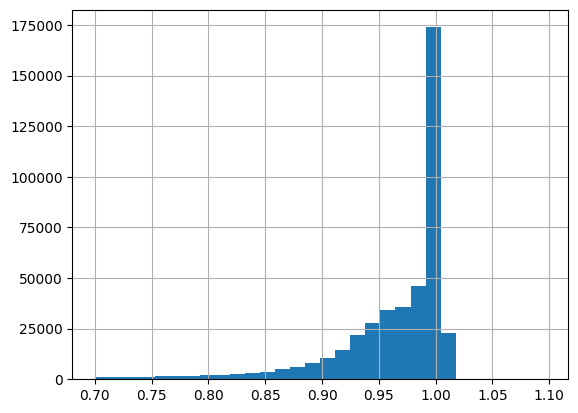

In [15]:
# Look at the distribution of coverage
hrv_raw["coverage"].hist(bins=30)

In [16]:
# Keep the ones with at least 80% coverage
hrv_raw = hrv_raw[hrv_raw["coverage"] >= 0.8]
hrv_raw

,id,study_interval,day_in_study,rmssd,coverage
1,2,2022,7,41.079,1.005
2,2,2022,7,42.649,0.970
3,2,2022,7,41.508,0.936
4,2,2022,7,40.232,1.006
5,2,2022,8,39.195,0.996
...,...,...,...,...,...
436257,50,2024,951,52.992,0.829
436258,50,2024,951,55.063,1.001
436259,50,2024,951,48.552,1.005
436260,50,2024,951,58.877,0.884


In [17]:
hrv_raw["rmssd"].describe()

count    418097.000000
mean         54.811037
std          34.342522
min           0.000000
25%          30.878000
50%          46.297000
75%          69.075000
max         686.934000
Name: rmssd, dtype: float64

In [18]:
hrv_daily = hrv_raw.groupby(JOIN_KEYS).agg(
    daily_hrv=('rmssd', 'median'),)

hrv_daily

daily_hrv
id study_interval day_in_study           
2  2022           7               41.2935
                  8               44.6445
                  9               46.3810
                  10              44.0465
                  11              40.6970
...                                   ...
50 2024           947             48.2100
                  948             44.0245
                  949             42.2470
                  950             51.2680
                  951             52.9920

[4838 rows x 1 columns]

### Sleep

In [19]:
# Look at the proportion of exact duplicate rows in sleep_score_raw
n_dup_rows = sleep_score_raw.duplicated().sum()
n_total_rows = len(sleep_score_raw)

print(f"Exact duplicate rows: {n_dup_rows}/{n_total_rows}")
print(f"Proportion: {n_dup_rows / n_total_rows:.2%}")

Exact duplicate rows: 61/5308
Proportion: 1.15%


In [20]:
# Remove exact duplicate rows, keeping the first occurrence
sleep_score_raw = sleep_score_raw.drop_duplicates()

sleep_score_raw

,id,study_interval,is_weekend,day_in_study,timestamp,overall_score,composition_score,revitalization_score,duration_score,deep_sleep_in_minutes,resting_heart_rate,restlessness
0,1,2022,False,4,07:42:00,80,21.0,22,37.0,93.0,84,0.056404
1,1,2022,True,7,10:04:30,81,18.0,21,42.0,86.0,82,0.035122
2,1,2022,False,11,08:03:00,83,21.0,23,39.0,53.0,76,0.047014
3,1,2022,False,12,08:06:00,80,19.0,22,39.0,49.0,77,0.051282
4,1,2022,False,20,09:35:00,82,18.0,19,45.0,113.0,76,0.075188
...,...,...,...,...,...,...,...,...,...,...,...,...
5303,50,2024,False,947,07:43:30,66,NaN,66,NaN,68.0,63,0.133333
5304,50,2024,False,948,07:33:30,65,NaN,65,NaN,72.0,63,0.103408
5305,50,2024,False,949,08:36:00,76,NaN,76,NaN,61.0,61,0.103486
5306,50,2024,False,950,08:11:00,81,NaN,81,NaN,71.0,61,0.094782


In [21]:
sleep_score_raw = sleep_score_raw[["id", "study_interval", "day_in_study", "timestamp", "overall_score"]]
sleep_score_raw

,id,study_interval,day_in_study,timestamp,overall_score
0,1,2022,4,07:42:00,80
1,1,2022,7,10:04:30,81
2,1,2022,11,08:03:00,83
3,1,2022,12,08:06:00,80
4,1,2022,20,09:35:00,82
...,...,...,...,...,...
5303,50,2024,947,07:43:30,66
5304,50,2024,948,07:33:30,65
5305,50,2024,949,08:36:00,76
5306,50,2024,950,08:11:00,81


Unparseable timestamps: 0/5247
Earliest: 00:09:30
Latest:   23:58:00


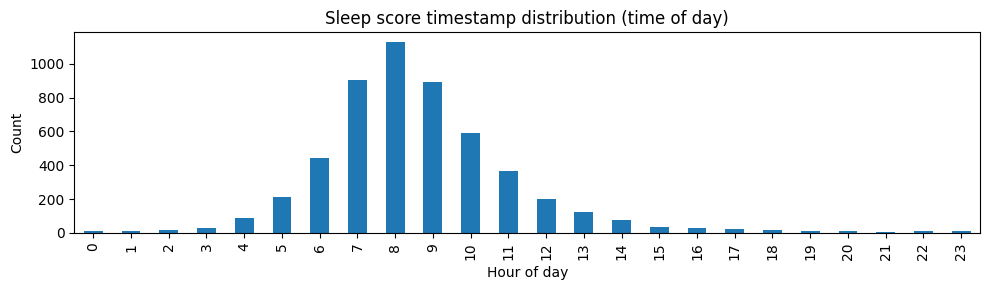

In [22]:
# Look at the distribution of timestamp (time-of-day)
ts = pd.to_timedelta(sleep_score_raw['timestamp'], errors='coerce')
print(f'Unparseable timestamps: {ts.isna().sum()}/{len(sleep_score_raw)}')

print('Earliest:', sleep_score_raw['timestamp'].min())
print('Latest:  ', sleep_score_raw['timestamp'].max())
ax = ts.dt.components['hours'].value_counts().sort_index().plot(kind='bar', figsize=(10, 3))
ax.set(xlabel='Hour of day', ylabel='Count', title='Sleep score timestamp distribution (time of day)')
plt.tight_layout()
plt.show()

ok, so likely it records the sleep of the night before, and `timestamp` here probably means something like "wake time". Thus, can use the value for that day.

In [23]:
sleep_score_raw

,id,study_interval,day_in_study,timestamp,overall_score
0,1,2022,4,07:42:00,80
1,1,2022,7,10:04:30,81
2,1,2022,11,08:03:00,83
3,1,2022,12,08:06:00,80
4,1,2022,20,09:35:00,82
...,...,...,...,...,...
5303,50,2024,947,07:43:30,66
5304,50,2024,948,07:33:30,65
5305,50,2024,949,08:36:00,76
5306,50,2024,950,08:11:00,81


In [24]:
# See if [`id`,`day_in_study`, `study_interval`] is unique in sleep_score_raw
sleep_score_raw[JOIN_KEYS].drop_duplicates().shape[0] == sleep_score_raw.shape[0]

False

In [25]:
# Which duplicates?
dup_mask = sleep_score_raw.duplicated(subset=JOIN_KEYS, keep=False)
sleep_score_raw[dup_mask].sort_values(JOIN_KEYS)

,id,study_interval,day_in_study,timestamp,overall_score
80,2,2022,51,17:41:00,49
81,2,2022,51,08:38:30,82
121,3,2022,2,18:46:30,55
122,3,2022,2,07:30:30,64
124,3,2022,4,22:15:00,58
...,...,...,...,...,...
5170,50,2022,60,08:45:30,78
5190,50,2022,80,08:44:00,70
5191,50,2022,80,05:36:30,73
5220,50,2024,868,13:59:00,67


In [26]:
sleep_score_raw["overall_score"].describe()

count    5247.000000
mean       76.710501
std         8.693726
min        30.000000
25%        72.000000
50%        78.000000
75%        83.000000
max        94.000000
Name: overall_score, dtype: float64

In [27]:
# If there are duplicates, take the ones before 12:00 PM (noon) and drop the rest
ts = pd.to_timedelta(sleep_score_raw['timestamp'], errors='coerce')
before_noon = ts.dt.components['hours'] < 12
is_dup_key = sleep_score_raw.duplicated(subset=JOIN_KEYS, keep=False)

n_before = len(sleep_score_raw)
drop_mask = is_dup_key & ~before_noon
sleep_score_raw = sleep_score_raw.loc[~drop_mask].reset_index(drop=True)

print(f'Dropped {drop_mask.sum()} duplicate-key rows at/after noon ({n_before} -> {len(sleep_score_raw)} rows)')

Dropped 129 duplicate-key rows at/after noon (5247 -> 5118 rows)


In [28]:
# For the rest of the duplicates (multiple ones before noon), take the latest one
n_before = len(sleep_score_raw)
sleep_score_raw = (
    sleep_score_raw.assign(_ts=pd.to_timedelta(sleep_score_raw['timestamp'], errors='coerce'))
    .sort_values(JOIN_KEYS + ['_ts'])
    .drop_duplicates(subset=JOIN_KEYS, keep='last')
    .drop(columns='_ts')
    .reset_index(drop=True)
)

print(f'After latest-before-noon dedup: {n_before} -> {len(sleep_score_raw)} rows')
print('JOIN_KEYS unique:', sleep_score_raw[JOIN_KEYS].drop_duplicates().shape[0] == len(sleep_score_raw))

After latest-before-noon dedup: 5118 -> 5072 rows
JOIN_KEYS unique: True


In [29]:
# drop feature "timestamp" since we only care about the overall score
sleep_score_raw = sleep_score_raw.drop(columns=['timestamp'])

In [ ]:
# rename "overall_score" to "sleep_score" for clarity
sleep_score_raw.rename(columns={'overall_score': 'sleep_score'}, inplace=True)

### Merge together

In [ ]:
# aggregate each raw table to one row per JOIN_KEYS

other_features_daily = (
    daily_glucose
    .merge(hrv_daily, on=JOIN_KEYS, how='outer')
    .merge(sleep_score_raw, on=JOIN_KEYS, how='outer')
)

OTHER_FEATURE_COLS = ['daily_glucose', 'daily_hrv', 'sleep_score']
other_features_daily

,id,study_interval,day_in_study,daily_glucose,daily_hrv,overall_score
0,1,2022,1,5.40,NaN,NaN
1,1,2022,2,5.30,NaN,NaN
2,1,2022,3,5.70,NaN,NaN
3,1,2022,4,5.05,NaN,80.0
4,1,2022,5,5.20,NaN,NaN
...,...,...,...,...,...,...
5516,50,2024,947,NaN,48.2100,66.0
5517,50,2024,948,NaN,44.0245,65.0
5518,50,2024,949,NaN,42.2470,76.0
5519,50,2024,950,NaN,51.2680,81.0


In [31]:
# merge with the main data table
df_main = load_fatigue_data('../../' + DATA_PATH)
merged = df_main.merge(other_features_daily, on=JOIN_KEYS, how='outer')

merged.head()

,day_in_study,id,study_interval,is_weekend,lightly,moderately,very,calories_sum,filtered_demographic_vo2_max,cardio_zone,...,fatigue_num,age_of_first_menarche,age,menstrual_health_literacy_num,sexually_active_num,lh_smooth,estrogen_smooth,daily_glucose,daily_hrv,overall_score
0,1,1,2022.0,True,4.174387,0.000000,0.000000,1542.0,33.79370,0.000000,...,4.0,14.0,25.0,NaN,1.0,2.90000,160.25,5.40,NaN,NaN
1,2,1,2022.0,False,4.317488,0.000000,0.000000,1591.0,32.55987,4.418841,...,4.0,14.0,25.0,NaN,1.0,2.05000,226.30,5.30,NaN,NaN
2,3,1,2022.0,False,4.905275,2.944439,2.079442,1755.0,31.50628,4.787492,...,5.0,14.0,25.0,NaN,1.0,2.77500,276.80,5.70,NaN,NaN
3,4,1,2022.0,False,4.465908,0.000000,0.000000,1552.0,31.06774,0.000000,...,4.0,14.0,25.0,NaN,1.0,2.28750,276.80,5.05,NaN,80.0
4,5,1,2022.0,False,2.397895,0.000000,0.000000,1456.0,30.88130,4.820282,...,4.0,14.0,25.0,NaN,1.0,3.44375,322.10,5.20,NaN,NaN


In [32]:
# Look at the proportion of exact duplicate rows in merged
n_dup_rows = merged.duplicated().sum()
n_total_rows = len(merged)

print(f"Exact duplicate rows: {n_dup_rows}/{n_total_rows}")
print(f"Proportion: {n_dup_rows / n_total_rows:.2%}")

Exact duplicate rows: 0/5591
Proportion: 0.00%


In [33]:
# handle missing values in other_features_daily, first check how many rows have missing values
# Number of missing values per column
missing_count = merged.isnull().sum()

# Percentage of missing values per column
missing_percent = ((merged.isnull().sum() / len(merged)) * 100).round(2)

# Combine into a table
missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percent": missing_percent
}).sort_values("Missing Percent", ascending=False)

print(missing_summary)

                               Missing Count  Missing Percent
daily_glucose                           2483            44.41
menstrual_health_literacy_num           2340            41.85
filtered_demographic_vo2_max            2260            40.42
calories_sum                            2260            40.42
moderately                              2260            40.42
very                                    2260            40.42
cardio_zone                             2260            40.42
fat_burn_zone                           2260            40.42
lightly                                 2260            40.42
is_weekend                              2260            40.42
age_of_first_menarche                   2260            40.42
fatigue_num                             2260            40.42
sexually_active_num                     2260            40.42
below_fat_burn_zone                     2260            40.42
estrogen                                2260            40.42
exercise

ONLY need to handle the new features' missingness: `daily_glucose`, `daily_hrv`, `sleep_score`. Since all other ones will be dealt with after only keeping rows that has `fatigue`.

In [34]:
# Use the per-participant median to fill in missing values for each of the other features
for col in OTHER_FEATURE_COLS:
    merged[col] = merged.groupby(['id'])[col].transform(lambda x: x.fillna(x.median()))

d:\ML-for-Women\.venv\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
d:\ML-for-Women\.venv\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [35]:
# Number of missing values per column
missing_count = merged.isnull().sum()

# Percentage of missing values per column
missing_percent = ((merged.isnull().sum() / len(merged)) * 100).round(2)

# Combine into a table
missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percent": missing_percent
}).sort_values("Missing Percent", ascending=False)

print(missing_summary)

                               Missing Count  Missing Percent
menstrual_health_literacy_num           2340            41.85
lightly                                 2260            40.42
filtered_demographic_vo2_max            2260            40.42
calories_sum                            2260            40.42
moderately                              2260            40.42
very                                    2260            40.42
cardio_zone                             2260            40.42
phase                                   2260            40.42
fat_burn_zone                           2260            40.42
is_weekend                              2260            40.42
age_of_first_menarche                   2260            40.42
age                                     2260            40.42
sexually_active_num                     2260            40.42
below_fat_burn_zone                     2260            40.42
estrogen                                2260            40.42
exercise

likely the 173 missing values are from 2 or 1 study intervals, which are missing the hrv data completely.

In [38]:
# Drop the 173 missing values in daily_hrv
merged = merged.dropna(subset=['daily_hrv'])

In [39]:
# Number of missing values per column
missing_count = merged.isnull().sum()

# Percentage of missing values per column
missing_percent = ((merged.isnull().sum() / len(merged)) * 100).round(2)

# Combine into a table
missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percent": missing_percent
}).sort_values("Missing Percent", ascending=False)

print(missing_summary)

                               Missing Count  Missing Percent
lightly                                 2240            41.34
is_weekend                              2240            41.34
filtered_demographic_vo2_max            2240            41.34
calories_sum                            2240            41.34
moderately                              2240            41.34
very                                    2240            41.34
cardio_zone                             2240            41.34
phase                                   2240            41.34
below_fat_burn_zone                     2240            41.34
fat_burn_zone                           2240            41.34
age                                     2240            41.34
menstrual_health_literacy_num           2240            41.34
sexually_active_num                     2240            41.34
lh                                      2240            41.34
estrogen                                2240            41.34
exercise

In [40]:
merged = merged.dropna(subset=['fatigue_num'])
merged

,day_in_study,id,study_interval,is_weekend,lightly,moderately,very,calories_sum,filtered_demographic_vo2_max,cardio_zone,...,fatigue_num,age_of_first_menarche,age,menstrual_health_literacy_num,sexually_active_num,lh_smooth,estrogen_smooth,daily_glucose,daily_hrv,overall_score
85,1,2,2022.0,True,4.499810,0.000000,0.000000,1568.00,39.95957,0.000000,...,2.0,13.0,29.0,3.0,1.0,2.900000,102.70,8.40,43.9695,87.0
86,2,2,2022.0,False,4.418841,0.000000,0.000000,1558.00,40.27132,0.000000,...,3.0,13.0,29.0,3.0,1.0,3.050000,126.90,6.50,43.9695,90.0
87,3,2,2022.0,False,4.465908,0.000000,0.000000,1579.00,40.48366,0.000000,...,2.0,13.0,29.0,3.0,1.0,4.375000,187.50,6.30,43.9695,89.0
88,4,2,2022.0,False,4.969813,3.295837,3.465736,1958.00,40.61939,0.000000,...,4.0,13.0,29.0,3.0,1.0,15.387500,220.30,6.30,43.9695,80.0
89,5,2,2022.0,False,4.753590,2.890372,3.135494,1804.00,40.61293,0.000000,...,4.0,13.0,29.0,3.0,1.0,17.443750,220.30,6.40,43.9695,71.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5483,86,50,2022.0,False,5.283204,3.178054,3.526361,2107.00,43.28141,1.609438,...,5.0,11.0,20.0,2.0,0.0,3.628999,54.60,6.30,47.9555,56.0
5484,87,50,2022.0,False,5.645447,2.639057,2.079442,2131.00,43.36550,0.693147,...,3.0,11.0,20.0,2.0,0.0,3.664499,28.10,6.30,54.4515,84.0
5485,88,50,2022.0,False,5.204007,0.000000,0.000000,1759.00,43.47867,0.000000,...,3.0,11.0,20.0,2.0,0.0,2.982250,22.10,6.70,57.6890,69.0
5486,89,50,2022.0,False,5.267858,3.433987,3.806662,2211.00,43.60040,0.000000,...,3.0,11.0,20.0,2.0,0.0,2.841125,20.85,6.95,62.2390,74.0


In [41]:
# Number of missing values per column
missing_count = merged.isnull().sum()

# Percentage of missing values per column
missing_percent = ((merged.isnull().sum() / len(merged)) * 100).round(2)

# Combine into a table
missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percent": missing_percent
}).sort_values("Missing Percent", ascending=False)

print(missing_summary)

                               Missing Count  Missing Percent
day_in_study                               0              0.0
id                                         0              0.0
study_interval                             0              0.0
is_weekend                                 0              0.0
lightly                                    0              0.0
moderately                                 0              0.0
very                                       0              0.0
calories_sum                               0              0.0
filtered_demographic_vo2_max               0              0.0
cardio_zone                                0              0.0
fat_burn_zone                              0              0.0
below_fat_burn_zone                        0              0.0
phase                                      0              0.0
lh                                         0              0.0
estrogen                                   0              0.0
exercise

## §4 Train / tune `catboost_ordinal`

Same participant hold-out and GroupKFold CV as [`3 fatigue_modeling.ipynb`](3%20fatigue_modeling.ipynb). Modeling uses the **preprocessed `merged`** frame from §3 (imputed other features, HRV required on every row, fatigue rows only). Features: base 17 + 3 history + `OTHER_FEATURE_COLS`.

In [ ]:
df = merged.sort_values(JOIN_KEYS).reset_index(drop=True)

strata = participant_strata(df)
train_val_ids, test_ids = split_participant_ids(df['id'].unique(), strata=strata)
train_val_mask = df['id'].isin(train_val_ids)
test_mask = df['id'].isin(test_ids)

df = preprocess_after_split(df, train_val_mask)  # literacy: train/val median only

bundle = build_split_bundle(df, train_val_ids, test_ids, train_val_mask, test_mask)

print(f'Rows: {len(df):,}  Participants: {df["id"].nunique()}')
print(f'Other features: {OTHER_FEATURE_COLS}')
display(split_summary_table(bundle))
print('Test participant ids:', sorted(bundle.test_ids))

Rows: 3,178  Participants: 40
Other features: ['daily_glucose', 'daily_hrv', 'overall_score']


,split,participants,rows,mean_fatigue
0,train_val,32,2536,2.673107
1,test,8,642,2.151090


Test participant ids: [np.int64(8), np.int64(15), np.int64(24), np.int64(33), np.int64(40), np.int64(44), np.int64(45), np.int64(48)]


In [43]:
def history_plus_other_matrices(bundle, other_cols, history_cols=HISTORY_FEATURES):
    """History pipeline matrices with optional extra columns from bundle.df."""
    X_tv, X_te, X_tv_tree, X_te_tree = history_feature_matrices(bundle, history_cols=history_cols)
    if other_cols:
        extra_tv = bundle.df.loc[bundle.train_val_mask, other_cols].reset_index(drop=True)
        extra_te = bundle.df.loc[bundle.test_mask, other_cols].reset_index(drop=True)
        X_tv = pd.concat([X_tv, extra_tv], axis=1)
        X_te = pd.concat([X_te, extra_te], axis=1)
        X_tv_tree = build_tree_matrix(X_tv)
        X_te_tree = build_tree_matrix(X_te)
    return X_tv_tree, X_te_tree

In [48]:
result = None
best_params = None

_name = 'catboost_ordinal'
X_train_val, X_test = history_plus_other_matrices(bundle, OTHER_FEATURE_COLS)

best_params, cv_score = tune_model(
    name=_name,
    registry=ORDINAL_MODELS,
    search_space=get_search_space(_name),
    X_train_val=X_train_val,
    y_train_val=bundle.y_ord_train_val,
    groups=bundle.groups_train_val,
    n_trials=OPTUNA_TRIALS,
    n_splits=N_CV_FOLDS,
    test_ids=bundle.test_ids,
)

factory = make_model_factory(_name, best_params, ORDINAL_MODELS)
result = run_model_benchmark(
    name=f'{_name}_history_other',
    model_factory=factory,
    X_train_val=X_train_val,
    X_test=X_test,
    y_train_val=bundle.y_ord_train_val,
    y_test=bundle.y_ord_test,
    groups=bundle.groups_train_val,
    n_splits=N_CV_FOLDS,
    test_ids=bundle.test_ids,
)
result['best_params'] = best_params
result['best_cv_score'] = cv_score

print('Best params:', best_params)
print(f'CV MAE ({N_CV_FOLDS}-fold): {cv_score:.4f}')


Best params: {'iterations': 464, 'depth': 4, 'learning_rate': 0.02581212991587459, 'l2_leaf_reg': 8.144552139322201}
CV MAE (5-fold): 0.8277


## §5 Testing

Merge diagnostics, comparison to the history-only reference from the main notebook, and CatBoost feature importance for the new columns.

In [49]:
REFERENCE_TEST_MAE = 0.8884  # catboost_ordinal_history from 3 fatigue_modeling.ipynb

test_mae = result['test_metrics']['mae']
delta_mae = test_mae - REFERENCE_TEST_MAE
summary = pd.DataFrame(
    [
        {
            'test_mae': test_mae,
            'reference_test_mae': REFERENCE_TEST_MAE,
            'delta_mae': delta_mae,
            'test_qwk': result['test_metrics']['qwk'],
        }
    ]
)
display(summary)
direction = 'improved' if delta_mae < 0 else 'worse'
print(f'delta_mae {delta_mae:+.4f} => other features {direction} vs history-only reference')

,test_mae,reference_test_mae,delta_mae,test_qwk
0,0.88785,0.8884,-0.00055,0.6206


delta_mae -0.0005 => other features improved vs history-only reference


Top 10 features overall


,feature,importance
0,fatigue_ewma,23.228315
1,fatigue_lag1,16.662174
2,fatigue_expanding_mean,11.794482
3,filtered_demographic_vo2_max,5.643819
4,sexually_active_num,5.556199
5,age,5.531714
6,daily_hrv,3.723820
7,menstrual_health_literacy_num,3.489049
8,estrogen_smooth,3.300709
9,lightly,2.733601


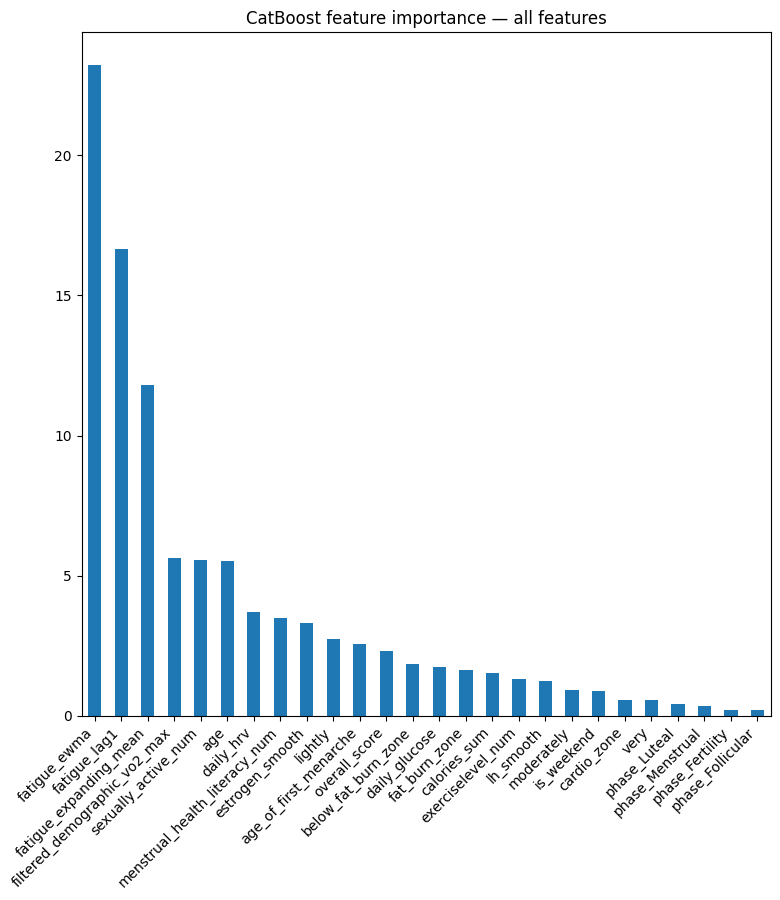

In [50]:
X_train_val, X_test = history_plus_other_matrices(bundle, OTHER_FEATURE_COLS)
_name = 'catboost_ordinal'
fitted = make_model_factory(_name, result['best_params'], ORDINAL_MODELS)()
fitted.fit(X_train_val, bundle.y_ord_train_val)

importances = fitted.model.get_feature_importance()
importance_df = (
    pd.DataFrame({'feature': X_train_val.columns, 'importance': importances})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

print('Top 10 features overall')
display(importance_df.head(100)) # show all

if not importance_df.empty and importance_df['importance'].sum() > 0:
    fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(importance_df))))
    importance_df.plot.bar(x='feature', y='importance', legend=False, ax=ax)
    ax.set_title('CatBoost feature importance — all features')
    ax.set_xlabel('')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()